<a href="https://colab.research.google.com/github/Ruba-Alharbi/MentalQA_NER-Reproduction/blob/main/RP1(F)_Few_shot_58_example_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

qr_df = pd.read_excel('58_full_df.xlsx', sheet_name= 'S2')

In [ ]:
# Normalize column names in both DataFrames
qr_df.columns = qr_df.columns.str.strip().str.lower()

# Confirm columns now
print(qr_df.columns)

Index(['unnamed: 0', 'question', 'medication mentioned', 'gpt-4o output',
       'llama output', 'allam output'],
      dtype='object')


In [ ]:
qr_df=qr_df.head(58)

In [ ]:
qr_df.head(2)

,unnamed: 0,question,medication mentioned,gpt-4o output,llama output,allam output
0,0,كنت اعانى من قلق واخدت دواء سبرالكس لمدة 4 شهو...,سبرالكس,"[{""Symptom"": ""قلق"", ""Diagnosis"": """", ""Treatmen...","[{""Symptom"": ""قلق"", ""Diagnosis"": """", ""Treatmen...","الإخراج:\n[{""Symptom"": ""كنت اعانى من قلق"", ""Di..."
1,1,عندي رهاب اجتماعي احس بديق النفس استعمل mediza...,"medizapin, s-citap, AVLOCARDYL","[{""Symptom"": ""ديق النفس، الافكار السلبية، النه...","[{""Symptom"": ""رهاب اجتماعي، ديق النفس، دهبة ال...","الإخراج:\n[{""Symptom"": ""رهاب اجتماعي، احس بديق..."


In [ ]:
# Loading zero-shot and few-shot files to each model
import pandas as pd

def build_merged(gold_path, gpt_path, llama_path, allam_path, out_path):
    gold = pd.read_excel(gold_path, sheet_name='S2')
    gold.columns = gold.columns.str.strip().str.lower()
    gold = gold.drop(columns=[c for c in gold.columns if c.startswith('unnamed')], errors='ignore')
    gold = gold[['question', 'medication mentioned']]

    gpt4o = pd.read_excel(gpt_path)
    llama = pd.read_excel(llama_path)
    allam = pd.read_excel(allam_path)


    print("GPT columns:", gpt4o.columns.tolist())
    print("LLaMA columns:", llama.columns.tolist())
    print("ALLaM columns:", allam.columns.tolist())

    gpt4o = gpt4o[['question', 'GPT-4o Output']].rename(columns={'GPT-4o Output': 'gpt-4o output'})
    llama = llama[['question', 'LLaMA Output']].rename(columns={'LLaMA Output': 'llama output'})
    allam = allam[['question', 'Allam Output']].rename(columns={'Allam Output': 'allam output'})

    merged = gold.merge(gpt4o, on='question', how='left') \
                 .merge(llama, on='question', how='left') \
                 .merge(allam, on='question', how='left')

    # Repair the one known question-text mismatch between the gold file
    # and the model-output files.

    anchor = "انا صيدلي"

    gold_match = gold[
        gold["question"].astype(str).str.contains(anchor, na=False)
    ]

    if len(gold_match) == 1:
        target_index = gold_match.index[0]

        for source_df, output_column in [
            (gpt4o, "gpt-4o output"),
            (llama, "llama output"),
            (allam, "allam output")
        ]:
            source_match = source_df[
                source_df["question"].astype(str).str.contains(anchor, na=False)
            ]

            if len(source_match) == 1:
                merged.loc[
                    target_index,
                    output_column
                ] = source_match.iloc[0][output_column]

    print(f"{out_path}: {merged.shape}")  #Expected shape: (58, 6)
    merged.to_excel(out_path, index=False)
    return merged

# Create the 58-question evaluation file for reproduced few-shot outputs
merged_fewshot_retried = build_merged(
    "58_full_df.xlsx",
    "all_models_fewshot_llama_retried.xlsx",
    "all_models_fewshot_llama_retried.xlsx",
    "all_models_fewshot_llama_retried.xlsx",
    "58_merged_fewshot_retried.xlsx"
)

#Create the 58-question evaluation file for reproduced zero-shot outputs
merged_zeroshot = build_merged(
    '58_full_df.xlsx',
    'zero-gpt4o_df.xlsx',
    'llama_df_zeroshot_retried.xlsx',
    'zero-allam_df.xlsx',
    '58_merged_zeroshot_retried.xlsx'
)

GPT columns: ['question', 'GPT-4o Output', 'LLaMA Output', 'Allam Output']
LLaMA columns: ['question', 'GPT-4o Output', 'LLaMA Output', 'Allam Output']
ALLaM columns: ['question', 'GPT-4o Output', 'LLaMA Output', 'Allam Output']
58_merged_fewshot_retried.xlsx: (58, 5)
GPT columns: ['Unnamed: 0', 'question', 'GPT-4o Output']
LLaMA columns: ['Unnamed: 0', 'question', 'GPT-4o Output', 'LLaMA Output']
ALLaM columns: ['question', 'Allam Output']
58_merged_zeroshot_retried.xlsx: (58, 5)


In [ ]:
for file_name in [
    "58_merged_fewshot_retried.xlsx",
    "58_merged_zeroshot_retried.xlsx"
]:
    check_df = pd.read_excel(file_name)

    prediction_columns = [
        "gpt-4o output",
        "llama output",
        "allam output"
    ]

    print(f"\n{file_name}")
    print(check_df[prediction_columns].isna().sum())

    llama_errors = (
        check_df["llama output"]
        .fillna("")
        .astype(str)
        .str.startswith("LLaMA Error:")
        .sum()
    )

    print(f"LLaMA API errors: {llama_errors}")


58_merged_fewshot_retried.xlsx
gpt-4o output    0
llama output     0
allam output     0
dtype: int64
LLaMA API errors: 0

58_merged_zeroshot_retried.xlsx
gpt-4o output    0
llama output     0
allam output     0
dtype: int64
LLaMA API errors: 0


In [ ]:
# Drop the unwanted 'unnamed: 0' column
#qr_df = qr_df.drop(columns=["unnamed: 0"])

# Check result
qr_df.head()

,question,medication mentioned,gpt-4o output,llama output,allam output
0,كنت اعانى من قلق واخدت دواء سبرالكس لمدة 4 شهو...,سبرالكس,"[{""Symptom"": ""قلق"", ""Diagnosis"": """", ""Treatmen...","[{""Symptom"": ""قلق"", ""Diagnosis"": """", ""Treatmen...","الإخراج:\n[{""Symptom"": ""قلق"", ""Diagnosis"": ""لا..."
1,عندي رهاب اجتماعي احس بديق النفس استعمل mediza...,"medizapin, s-citap, AVLOCARDYL","[{""Symptom"": ""ديق النفس، النهجة، الكسل"", ""Diag...","[{""Symptom"": ""رهاب اجتماعي، ديق النفس، دهبة ال...","الإجابة:\n[{""Symptom"": ""رهاب اجتماعي"", ""Diagno..."
2,السلام عليكم سبق وأن أستفسرت وأفادني أحد الأطب...,"Aripiprazole, أريبيبرازول, esciatalopram, السر...","[{""Symptom"": """", ""Diagnosis"": ""الانتكاسه، الاك...","[{""Symptom"": """", ""Diagnosis"": ""الاكتئاب"", ""Tre...","الإخراج:\n[{""Symptom"": ""منع الانتكاسه، ضبط الم..."
3,"اعاني من القلق , وصفلي الدكتور لوسترال ٥٠ ملج ...",لوسترال,"[{""Symptom"": ""القلق"", ""Diagnosis"": """", ""Treatm...","[{""Symptom"": ""القلق"", ""Diagnosis"": """", ""Treatm...","الإخراج:\n[{""Symptom"": ""القلق"", ""Diagnosis"": ""..."
4,هل حبوب ميرزاجن لها اضرار,ميرزاجن,"[{""Symptom"": """", ""Diagnosis"": """", ""Treatment"":...","[{""Symptom"": """", ""Diagnosis"": """", ""Treatment"":...","الإخراج:\n[{""Symptom"": """", ""Diagnosis"": """", ""T..."


In [ ]:
#print(pd.read_excel('gpt4o_df.xlsx').columns.tolist())
#print(pd.read_excel('llama_df.xlsx').columns.tolist())
#print(pd.read_excel('allam_df.xlsx').columns.tolist())

## Extract Drug Entity


In [ ]:
import re
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the final merged file

#qr_df = qr_df = pd.read_excel("58_merged_fewshot_retried.xlsx",sheet_name=0) # for few-shot
qr_df = pd.read_excel("58_merged_zeroshot_retried.xlsx",sheet_name=0) # for zero-shot
df = qr_df.copy()

In [ ]:
# ====== Fresh cleaning pipeline (explicit columns; no auto-detect) ======
import re, pandas as pd

# ---------- Splitters / patterns ----------
# split on commas/Arabic commas/semicolons and common Arabic connectors (and/or/from/to/then)
_SEP = re.compile(r'[,\u060C;؛]|\s+(?:و|او|أو|من|عن|الى|إلى|ثم)\s+', re.IGNORECASE)

_DRUG_FIELD  = re.compile(r'"Drug"\s*:\s*(?:"([^"]*)"|\[(.*?)\])', re.IGNORECASE | re.DOTALL)
_PLAIN_FIELD = re.compile(r'\bDrug\s*[:：]\s*([^\n\r]+)', re.IGNORECASE)

# Numbers (EN + Arabic-Indic) and units
_NUM   = r'[\d\u0660-\u0669]'
_UNITS = r'(?:mg|ml|mcg|ug|g|iu|ملجم|مجم|مل|قرص|أقراص|اقراص|حبة|حبه|قطرة|جرعة|أمبول|امبول|حقنة|حقن)'

# Arabic definite article (with clitics), e.g., والـ، بالـ، للـ …
_AR_ARTICLE_RE = re.compile(r'^(?:[وفبكل]\s*)?(?:ال|أل|إل|آل|لل)ـ?\s*', re.IGNORECASE)

# Leading prepositions inside tokens (e.g., "من انديرال" -> "انديرال")
_AR_PREP_PREFIX_RE = re.compile(r'^(?:من|عن|الى|إلى|على|مع|بدون|بلا)\s+', re.IGNORECASE)

# Generic dosage-form / filler words (removed anywhere)
_GENERIC_WORDS = (
    r'اسم(?:ه|ها)?|غير\s*معروف|دواء|الدواء|ادوية|الأدوية|دوا|'
    r'برشام|'
    r'قرص|أقراص|اقراص|حبة|حبه|حبوب|'
    r'كبسول(?:ة|ات)?|'
    r'شراب|'
    r'مرهم|كريم|جل|محلول|لاصقة|'
    r'بخاخ|بخّاخ|'
    r'قطرة|قطرات|'
    r'حقنة|حقن|أمبول|امبول|امبولات|'
    r'مهدئ|مسكن|منوم|'
    r'مضاد(?:\s+حيوي)?'
)
_GENERIC_INLINE_RE = re.compile(rf'\b(?:{_GENERIC_WORDS})\b', re.IGNORECASE)

# Tokens to drop completely if they remain alone
_DROP_TOKENS = {
    "و","او","أو","من","عن","على","الى","إلى","ثم","في","مع","بدون","بلا",
    "اسم","اسمه","اسمها","الدواء","دواء","دوا","برشام","حبة","حبوب",
    "قرص","اقراص","أقراص","حقنة","حقن","امبول","أمبول","شراب",
    "مرهم","كريم","جل","بخاخ","قطرة","قطرات","لبوس","تحاميل","تحميلة",
    "غير","معروف"
}
_HAS_DIGIT_RE = re.compile(r'[\d\u0660-\u0669]')

In [ ]:
def _strip_noise(s: str) -> str:
    """Remove numbers/units and filler words anywhere in the token."""
    # number+unit and bare numbers anywhere (no word boundaries)
    s = re.sub(fr'{_NUM}+(?:[.,]{_NUM}+)?\s*{_UNITS}', ' ', s, flags=re.IGNORECASE)
    s = re.sub(fr'{_NUM}+(?:[.,]{_NUM}+)?', ' ', s)
    # generic/filler words
    s = _GENERIC_INLINE_RE.sub(' ', s)
    return s

In [ ]:
def clean_drug_name(name: str) -> str:
    """Normalize one token until only a plausible drug name remains."""
    s = str(name).strip().lower()

    # drop article and leading prepositions inside the token
    s = _AR_ARTICLE_RE.sub('', s)
    s = _AR_PREP_PREFIX_RE.sub('', s)

    # remove inline noise (numbers+units, dosage forms, 'اسمه/اسمها', 'دواء غير معروف', etc.)
    s = _strip_noise(s)

    # keep only letters/digits/-/+; squeeze spaces and trim
    s = re.sub(r'[^\w\-\+]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip(' -+ ').strip()

    # drop if empty, still has digits, is a stop token, or is a single letter
    if (not s) or _HAS_DIGIT_RE.search(s) or (s in _DROP_TOKENS) or len(s) == 1:
        return ""
    return s

In [ ]:
def extract_drugs_from_model(text) -> list[str]:
    """Pull Drug values from JSON-like or plain text, clean, and dedupe."""
    if not isinstance(text, str) or not text.strip():
        return []
    drugs = []

    # JSON-like: "Drug": "..."  or  "Drug": ["a","b"]
    for m in _DRUG_FIELD.finditer(text):
        payload = (m.group(1) if m.group(1) is not None else m.group(2)) or ""
        payload = payload.replace('"', '').replace("'", '')
        for part in _SEP.split(payload):
            part = clean_drug_name(part)
            if part:
                drugs.append(part)

    # Fallback: plain "Drug: a, b"
    for m in _PLAIN_FIELD.finditer(text):
        payload = m.group(1)
        for part in _SEP.split(payload):
            part = clean_drug_name(part)
            if part:
                drugs.append(part)

    # dedupe preserving order
    seen, out = set(), []
    for d in drugs:
        if d and d not in seen:
            seen.add(d); out.append(d)
    return out

In [ ]:
def normalize_annotated(val) -> list[str]:
    """Normalize the ground-truth column to a list of clean names + dedupe."""
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, list):
        parts = val
    else:
        text = str(val).strip().strip('[]').replace('"', '').replace("'", '')
        parts = [p for p in _SEP.split(text) if p.strip()]

    seen, out = set(), []
    for p in parts:
        c = clean_drug_name(p)
        if c and c not in seen:
            seen.add(c); out.append(c)
    return out

In [ ]:
def apply_cleaning(df: pd.DataFrame, *, med_col: str, model_cols: list[str], joiner: str = ", "):
    """Cleans in-place and returns df with strings (no lists). Requires explicit columns."""
    # drop 'unnamed' style columns (from index in CSV/Excel)
    df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")],
            inplace=True, errors="ignore")

    # sanity checks
    missing = [c for c in [med_col, *model_cols] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    # normalize annotated -> join
    df[med_col] = df[med_col].apply(normalize_annotated).apply(lambda xs: joiner.join(xs))

    # extract from each model output -> join
    for col in model_cols:
        df[col] = df[col].apply(extract_drugs_from_model).apply(lambda xs: joiner.join(xs))

    # move medication next to question if present
    if "question" in df.columns:
        cols = list(df.columns)
        cols.insert(cols.index("question")+1, cols.pop(cols.index(med_col)))
        df = df[cols]

    return df

In [ ]:
MED_COL    = "medication mentioned"
MODEL_COLS = ["gpt-4o output", "llama output", "allam output"]

In [ ]:
df = apply_cleaning(df, med_col=MED_COL, model_cols=MODEL_COLS, joiner=", ")
display(df.head(58))

,question,medication mentioned,gpt-4o output,llama output,allam output
0,كنت اعانى من قلق واخدت دواء سبرالكس لمدة 4 شهو...,سبرالكس,سبرالكس,سبرالكس,
1,عندي رهاب اجتماعي احس بديق النفس استعمل mediza...,"medizapin, s-citap, avlocardyl","medizapin, s-citap, avlocardyl","medizapin, s-citap, avlocardyl",medizapin كل ليلة
2,السلام عليكم سبق وأن أستفسرت وأفادني أحد الأطب...,"aripiprazole, أريبيبرازول, esciatalopram, سركويل","أريبيبرازول aripiprazole, esciatalopram, سركويل",aripiprazole,أريبيبرازول aripiprazole
3,"اعاني من القلق , وصفلي الدكتور لوسترال ٥٠ ملج ...",لوسترال,لوسترال,لوسترال,لوسترال
4,هل حبوب ميرزاجن لها اضرار,ميرزاجن,ميرزاجن,ميرزاجن,ميرزاجن
5,رجاء أريد معلومات عن دواء جديد اسمه Ixel Milna...,ixel milnacipran,ixel milnacipran,ixel milnacipran,ixel milnacipran
6,انا فيني اكتئاب وقلق ووصف لي دكتورcitalopram ا...,"citalopram, ativan","citalopram, ativan","citalopram, ativan",citalopram
7,الاعراض الانسحابية للاستالوبرام قوية علي عندما...,استالوبرام,استالوبرام,استالوبرام,استالوبرام
8,باخد اولابكس olapex و بريانيل prianil بقالي تس...,"اولابكس, بريانيل, سرترالين, مودابكس, سيرباس ol...","اولابكس olapex, بريانيل prianil, سرترالين, mod...","اولابكس, بريانيل, سرترالين, مودابكس, serpass س...",اولابكس olapex
9,اخذت دواء سيروكسات ٢٥ لمدة ثلاث شهور وتركته ٥ا...,سيروكسات,سيروكسات,سيروكسات,سيروكسات


## Evaluation

In [ ]:
# 1) Splitter: comma, Arabic comma "،", semicolons, and the Arabic "و" when used as "and"
_SEP = re.compile(r'[,\u060C;؛]|\s+و\s+', re.IGNORECASE)

def autodetect_cols(df: pd.DataFrame):
    """Find ground-truth and model columns by name (case-insensitive)."""
    truth_col = None
    for c in df.columns:
        lc = c.strip().lower()
        if "medication" in lc and "mention" in lc:
            truth_col = c
            break
    if truth_col is None:
        raise ValueError("Couldn't find the 'medication mentioned' column.")

    model_cols = [c for c in df.columns if "output" in c.lower()]
    if not model_cols:
        raise ValueError("Couldn't find any model output columns (names containing 'output').")
    return truth_col, model_cols

def to_set(val) -> set:
    """Turn a cell into a set of tokens with only splitting+trimming (no cleaning)."""
    if isinstance(val, list):
        parts = val
    else:
        text = "" if (val is None or (isinstance(val, float) and pd.isna(val))) else str(val)
        parts = _SEP.split(text)
    return {p.strip() for p in parts if str(p).strip()}

def evaluate(df: pd.DataFrame, truth_col=None, model_cols=None):
    """Micro-averaged P/R/F1 for each model with no additional normalization."""
    if truth_col is None or model_cols is None:
        truth_col, model_cols = autodetect_cols(df)

    y_true_sets = df[truth_col].apply(to_set)

    rows = []
    for col in model_cols:
        y_pred_sets = df[col].apply(to_set)

        TP = FP = FN = 0
        for t, p in zip(y_true_sets, y_pred_sets):
            TP += len(t & p)
            FP += len(p - t)
            FN += len(t - p)

        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0

        name = col.replace(" output", "").replace("Output", "").strip()
        print(f"{name}:\n  Precision: {precision:.2f}\n  Recall:    {recall:.2f}\n  F1 Score:  {f1:.2f}\n")
        rows.append((name, f1, precision, recall))

    summary = pd.DataFrame(rows, columns=["Model", "F1 Score", "Precision", "Recall"])
    summary = summary.round(2)

    return summary


summary = evaluate(df)
display(summary)

gpt-4o:
  Precision: 0.91
  Recall:    0.84
  F1 Score:  0.87

llama:
  Precision: 0.93
  Recall:    0.83
  F1 Score:  0.88

allam:
  Precision: 0.70
  Recall:    0.45
  F1 Score:  0.55



,Model,F1 Score,Precision,Recall
0,gpt-4o,0.87,0.91,0.84
1,llama,0.88,0.93,0.83
2,allam,0.55,0.70,0.45


# Error Analysis

## Few-shot

In [ ]:
# Create item-level Drug error records for the few-shot evaluation
# using the same cleaned values used by the published F1 evaluation.

import re
import pandas as pd

condition = "few_shot"

gold_column = "medication mentioned"

model_columns = {
    "GPT-4o": "gpt-4o output",
    "LLaMA": "llama output",
    "ALLaM": "allam output",
}

splitter = re.compile(r"[,،;؛]|\s+و\s+")

def to_drug_set(value):
    text = "" if pd.isna(value) else str(value)
    return {item.strip() for item in splitter.split(text) if item.strip()}

records = []

for row_id, row in df.iterrows():
    gold = to_drug_set(row[gold_column])

    for model_name, column_name in model_columns.items():
        prediction = to_drug_set(row[column_name])

        false_negatives = gold - prediction
        false_positives = prediction - gold

        if not false_negatives and not false_positives:
            error_shape = "exact"
        elif false_negatives and false_positives:
            error_shape = "mixed"
        elif false_negatives:
            error_shape = "false_negative_only"
        else:
            error_shape = "false_positive_only"

        records.append({
            "condition": condition,
            "row_id": row_id,
            "model": model_name,
            "question": row["question"],
            "gold_drugs": ", ".join(sorted(gold)),
            "predicted_drugs": ", ".join(sorted(prediction)),
            "false_negatives": ", ".join(sorted(false_negatives)),
            "false_positives": ", ".join(sorted(false_positives)),
            "gold_mention_count": len(gold),
            "prediction_mention_count": len(prediction),
            "input_type": "multiple_drugs" if len(gold) > 1 else "single_drug",
            "error_shape": error_shape,
            "is_error": error_shape != "exact",
        })

all_items = pd.DataFrame(records)
errors_only = all_items[all_items["is_error"]].copy()

by_input_type = (
    all_items
    .groupby(["model", "input_type"], as_index=False)
    .agg(
        items=("row_id", "count"),
        error_records=("is_error", "sum"),
        error_rate=("is_error", "mean"),
        false_negative_mentions=(
            "false_negatives",
            lambda values: sum(len(to_drug_set(value)) for value in values)
        ),
        false_positive_mentions=(
            "false_positives",
            lambda values: sum(len(to_drug_set(value)) for value in values)
        ),
    )
)

by_error_shape = (
    all_items
    .groupby(["model", "error_shape"], as_index=False)
    .size()
    .rename(columns={"size": "records"})
)

output_file = "few_shot_drug_error_analysis_retried.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    all_items.to_excel(writer, sheet_name="all_items", index=False)
    errors_only.to_excel(writer, sheet_name="errors_only", index=False)
    by_input_type.to_excel(writer, sheet_name="by_input_type", index=False)
    by_error_shape.to_excel(writer, sheet_name="by_error_shape", index=False)

print(f"Saved {output_file}")

display(by_input_type)
display(by_error_shape)

Saved few_shot_drug_error_analysis_retried.xlsx


,model,input_type,items,error_records,error_rate,false_negative_mentions,false_positive_mentions
0,ALLaM,multiple_drugs,21,10,0.476190,20,14
1,ALLaM,single_drug,37,8,0.216216,4,7
2,GPT-4o,multiple_drugs,21,7,0.333333,6,5
3,GPT-4o,single_drug,37,2,0.054054,2,2
4,LLaMA,multiple_drugs,21,8,0.380952,13,6
5,LLaMA,single_drug,37,2,0.054054,2,2


,model,error_shape,records
0,ALLaM,exact,40
1,ALLaM,false_negative_only,3
2,ALLaM,false_positive_only,5
3,ALLaM,mixed,10
4,GPT-4o,exact,49
5,GPT-4o,false_negative_only,3
6,GPT-4o,false_positive_only,1
7,GPT-4o,mixed,5
8,LLaMA,exact,48
9,LLaMA,false_negative_only,2


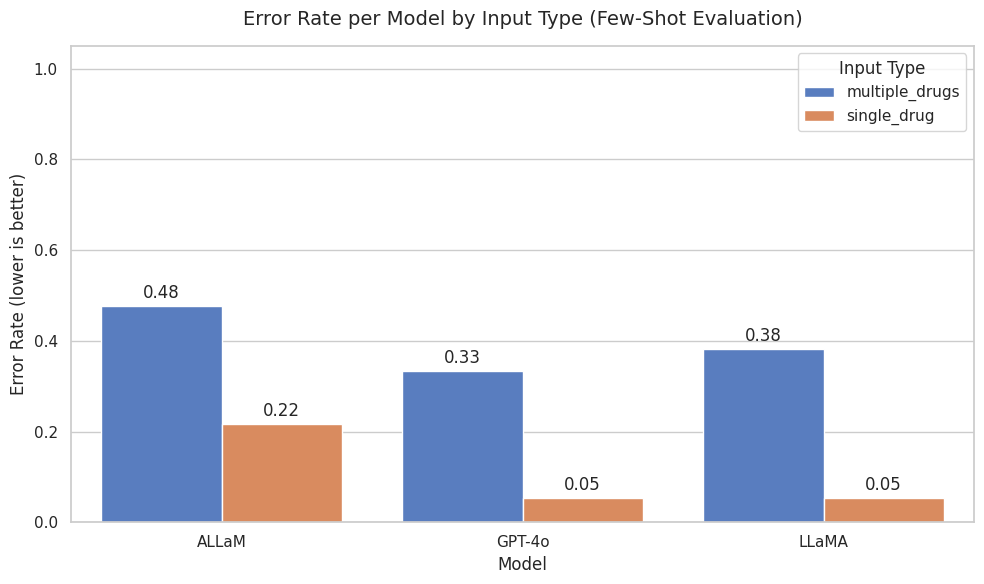

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Create grouped bar chart
sns.barplot(
    data=by_input_type,
    x="model",
    y="error_rate",
    hue="input_type",
    palette="muted",
    ax=ax
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Error Rate per Model by Input Type (Few-Shot Evaluation)", fontsize=14, pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Error Rate (lower is better)", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Input Type")
plt.tight_layout()
plt.show()

## Zero-shot

In [ ]:
# Create item-level Drug error records for the zero-shot evaluation
# using the same cleaned values used by the published F1 evaluation.

import re
import pandas as pd

condition = "zero_shot"

gold_column = "medication mentioned"

model_columns = {
    "GPT-4o": "gpt-4o output",
    "LLaMA": "llama output",
    "ALLaM": "allam output",
}

splitter = re.compile(r"[,،;؛]|\s+و\s+")

def to_drug_set(value):
    text = "" if pd.isna(value) else str(value)
    return {item.strip() for item in splitter.split(text) if item.strip()}

records = []

for row_id, row in df.iterrows():
    gold = to_drug_set(row[gold_column])

    for model_name, column_name in model_columns.items():
        prediction = to_drug_set(row[column_name])

        false_negatives = gold - prediction
        false_positives = prediction - gold

        if not false_negatives and not false_positives:
            error_shape = "exact"
        elif false_negatives and false_positives:
            error_shape = "mixed"
        elif false_negatives:
            error_shape = "false_negative_only"
        else:
            error_shape = "false_positive_only"

        records.append({
            "condition": condition,
            "row_id": row_id,
            "model": model_name,
            "question": row["question"],
            "gold_drugs": ", ".join(sorted(gold)),
            "predicted_drugs": ", ".join(sorted(prediction)),
            "false_negatives": ", ".join(sorted(false_negatives)),
            "false_positives": ", ".join(sorted(false_positives)),
            "gold_mention_count": len(gold),
            "prediction_mention_count": len(prediction),
            "input_type": "multiple_drugs" if len(gold) > 1 else "single_drug",
            "error_shape": error_shape,
            "is_error": error_shape != "exact",
        })

all_items = pd.DataFrame(records)
errors_only = all_items[all_items["is_error"]].copy()

by_input_type = (
    all_items
    .groupby(["model", "input_type"], as_index=False)
    .agg(
        items=("row_id", "count"),
        error_records=("is_error", "sum"),
        error_rate=("is_error", "mean"),
        false_negative_mentions=(
            "false_negatives",
            lambda values: sum(len(to_drug_set(value)) for value in values)
        ),
        false_positive_mentions=(
            "false_positives",
            lambda values: sum(len(to_drug_set(value)) for value in values)
        ),
    )
)

by_error_shape = (
    all_items
    .groupby(["model", "error_shape"], as_index=False)
    .size()
    .rename(columns={"size": "records"})
)

output_file = "zero_shot_drug_error_analysis_retried.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    all_items.to_excel(writer, sheet_name="all_items", index=False)
    errors_only.to_excel(writer, sheet_name="errors_only", index=False)
    by_input_type.to_excel(writer, sheet_name="by_input_type", index=False)
    by_error_shape.to_excel(writer, sheet_name="by_error_shape", index=False)

print(f"Saved {output_file}")

display(by_input_type)
display(by_error_shape)

Saved zero_shot_drug_error_analysis_retried.xlsx


,model,input_type,items,error_records,error_rate,false_negative_mentions,false_positive_mentions
0,ALLaM,multiple_drugs,21,18,0.857143,45,13
1,ALLaM,single_drug,37,9,0.243243,9,6
2,GPT-4o,multiple_drugs,21,7,0.333333,14,6
3,GPT-4o,single_drug,37,2,0.054054,2,2
4,LLaMA,multiple_drugs,21,9,0.428571,14,3
5,LLaMA,single_drug,37,3,0.081081,3,3


,model,error_shape,records
0,ALLaM,exact,31
1,ALLaM,false_negative_only,11
2,ALLaM,mixed,16
3,GPT-4o,exact,49
4,GPT-4o,false_negative_only,4
5,GPT-4o,mixed,5
6,LLaMA,exact,46
7,LLaMA,false_negative_only,6
8,LLaMA,mixed,6


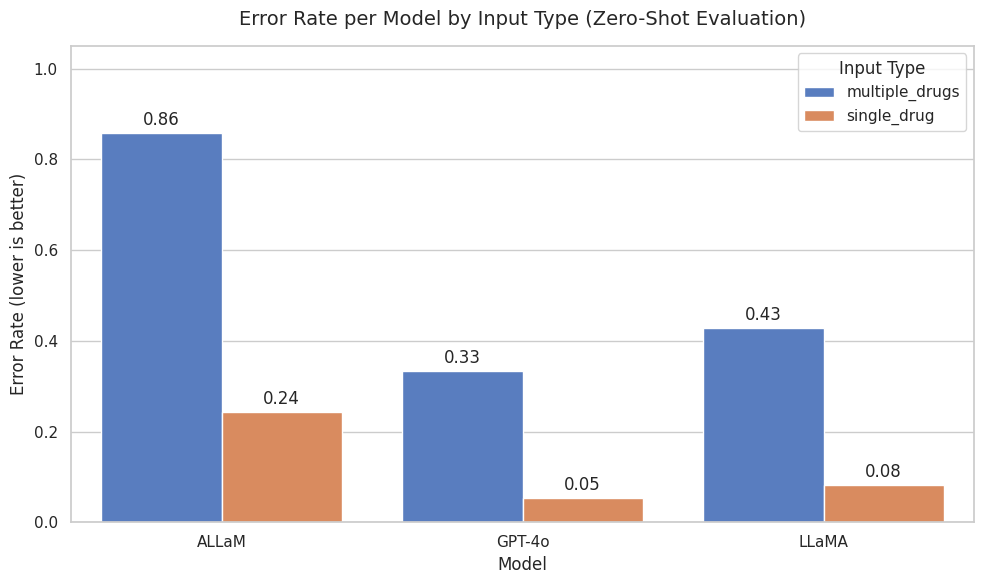

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Create grouped bar chart for zero-shot evaluation
sns.barplot(
    data=by_input_type,
    x="model",
    y="error_rate",
    hue="input_type",
    palette="muted",
    ax=ax
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Error Rate per Model by Input Type (Zero-Shot Evaluation)", fontsize=14, pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Error Rate (lower is better)", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Input Type")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the computed error analysis summaries from both sheets
few_shot_summary = pd.read_excel("few_shot_drug_error_analysis_retried.xlsx", sheet_name="by_input_type")
few_shot_summary["evaluation"] = "Few-Shot"

zero_shot_summary = pd.read_excel("zero_shot_drug_error_analysis_retried.xlsx", sheet_name="by_input_type")
zero_shot_summary["evaluation"] = "Zero-Shot"

# Combine them
comparison_df = pd.concat([few_shot_summary, zero_shot_summary], ignore_index=True)

# Display the structured comparison table
display(comparison_df[["evaluation", "model", "input_type", "items", "error_records", "error_rate"]])

,evaluation,model,input_type,items,error_records,error_rate
0,Few-Shot,ALLaM,multiple_drugs,21,10,0.476190
1,Few-Shot,ALLaM,single_drug,37,8,0.216216
2,Few-Shot,GPT-4o,multiple_drugs,21,7,0.333333
3,Few-Shot,GPT-4o,single_drug,37,2,0.054054
4,Few-Shot,LLaMA,multiple_drugs,21,8,0.380952
5,Few-Shot,LLaMA,single_drug,37,2,0.054054
6,Zero-Shot,ALLaM,multiple_drugs,21,18,0.857143
7,Zero-Shot,ALLaM,single_drug,37,9,0.243243
8,Zero-Shot,GPT-4o,multiple_drugs,21,7,0.333333
9,Zero-Shot,GPT-4o,single_drug,37,2,0.054054


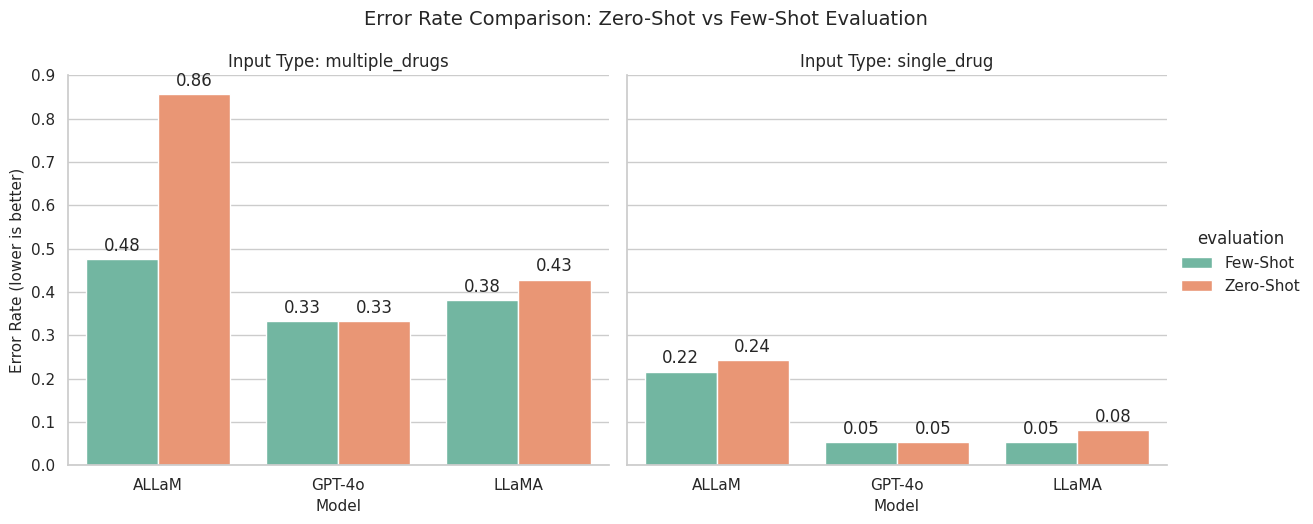

In [ ]:
# 2. Plotting the comparison side-by-side
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=comparison_df,
    kind="bar",
    x="model",
    y="error_rate",
    hue="evaluation",
    col="input_type",
    palette="Set2",
    height=5,
    aspect=1.2
)

# Add exact value labels on the bars
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    ax.set_ylabel("Error Rate (lower is better)", fontsize=11)
    ax.set_xlabel("Model", fontsize=11)

g.set_titles("Input Type: {col_name}")
g.fig.suptitle("Error Rate Comparison: Zero-Shot vs Few-Shot Evaluation", y=1.05, fontsize=14)
plt.show()